# Davis Southern Women Network Analysis

### Instructions
Here is a dataset that shows a simple 2-node network:  the attendance of 18 Southern Women at 14 social events:

Brief Description. 
- Small “musty” datasets like that from this 1941 study have proven very valuable in testing and comparing new network algorithms.
- Dataset.
- Python code to create dataset: https://networkx.github.io/documentation/stable/auto_examples/algorithms/plot_davis_club.html
What can you infer about the relationships between (1) the women, and (2) the social events?  

### Code Below take nfrom Provided URL

In [2]:
import matplotlib.pyplot as plt
import networkx as nx
from networkx.algorithms import bipartite

## Loading the data 
G = nx.davis_southern_women_graph()
women = G.graph["top"]
clubs = G.graph["bottom"]

## Printing out the values present 
print("Biadjacency matrix")
print(bipartite.biadjacency_matrix(G, women, clubs))

Biadjacency matrix
<Compressed Sparse Row sparse array of dtype 'int64'
	with 89 stored elements and shape (18, 14)>
  Coords	Values
  (0, 0)	1
  (0, 1)	1
  (0, 2)	1
  (0, 3)	1
  (0, 4)	1
  (0, 5)	1
  (0, 7)	1
  (0, 8)	1
  (1, 0)	1
  (1, 1)	1
  (1, 2)	1
  (1, 4)	1
  (1, 5)	1
  (1, 6)	1
  (1, 7)	1
  (2, 1)	1
  (2, 2)	1
  (2, 3)	1
  (2, 4)	1
  (2, 5)	1
  (2, 6)	1
  (2, 7)	1
  (2, 8)	1
  (3, 0)	1
  (3, 2)	1
  :	:
  (12, 7)	1
  (12, 8)	1
  (12, 9)	1
  (12, 11)	1
  (12, 12)	1
  (12, 13)	1
  (13, 5)	1
  (13, 6)	1
  (13, 8)	1
  (13, 9)	1
  (13, 10)	1
  (13, 11)	1
  (13, 12)	1
  (13, 13)	1
  (14, 6)	1
  (14, 7)	1
  (14, 9)	1
  (14, 10)	1
  (14, 11)	1
  (15, 7)	1
  (15, 8)	1
  (16, 8)	1
  (16, 10)	1
  (17, 8)	1
  (17, 10)	1



#Friends, Member
17 Evelyn Jefferson
15 Laura Mandeville
17 Theresa Anderson
15 Brenda Rogers
11 Charlotte McDowd
15 Frances Anderson
15 Eleanor Nye
16 Pearl Oglethorpe
17 Ruth DeSand
17 Verne Sanderson
16 Myra Liddel
16 Katherina Rogers
17 Sylvia Avondale
17 Nora Fayette
17 Helen Lloyd
16 Dorothy Murchison
12 Olivia Carleton
12 Flora Price

#Friend meetings, Member
50 Evelyn Jefferson
45 Laura Mandeville
57 Theresa Anderson
46 Brenda Rogers
24 Charlotte McDowd
32 Frances Anderson
36 Eleanor Nye
31 Pearl Oglethorpe
40 Ruth DeSand
38 Verne Sanderson
33 Myra Liddel
37 Katherina Rogers
46 Sylvia Avondale
43 Nora Fayette
34 Helen Lloyd
24 Dorothy Murchison
14 Olivia Carleton
14 Flora Price


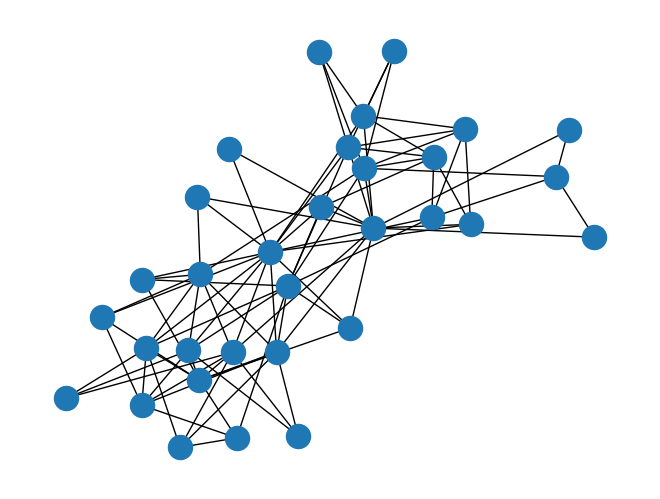

In [3]:
# Making the network nodes project bipartite graph for women
W = bipartite.projected_graph(G, women)
print()
print("#Friends, Member")
for w in women:
    print(f"{W.degree(w)} {w}")

# project bipartite graph onto women nodes keeping number of co-occurrence
# the degree computed is weighted and counts the total number of shared contacts
W = bipartite.weighted_projected_graph(G, women)
print()
print("#Friend meetings, Member")
for w in women:
    print(f"{W.degree(w, weight='weight')} {w}")

pos = nx.spring_layout(G, seed=648)  # Seed layout for reproducible node positions
nx.draw(G, pos)
plt.show()

### Initial Set up explanation.
Just read in the raw data and displayed the data from the provided url in the assignment text. This only made edges only connecting women to events. Not women to women or events to events. 

THis code also added weights for number of appearances together for highlighting the social networks, it made bipartite network into a 1-node network for women - women connections. Essentially deriving social network connections from event attendance. 

### Start of Analysis for Week 6 - Additional Assumptions that can be made

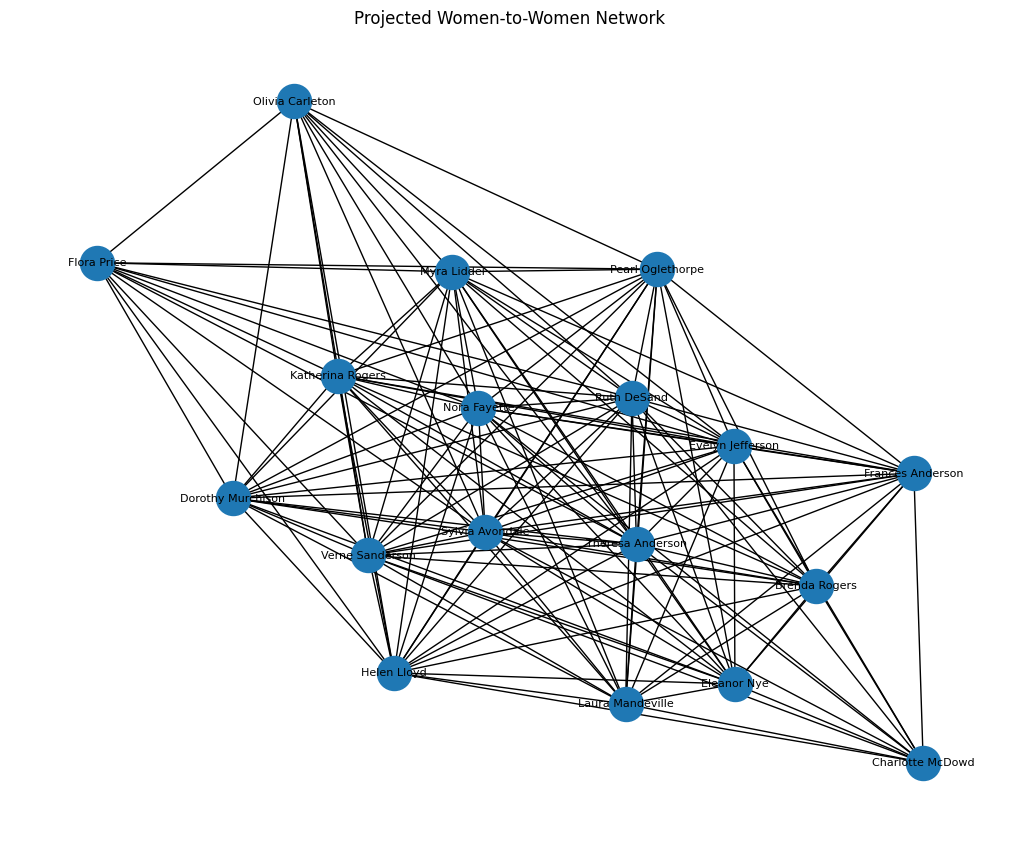

In [11]:
### Adding Women only viz better labeled etc.
plt.figure(figsize=(10, 8))

pos_w = nx.spring_layout(W, seed=648)
nx.draw(W, pos_w, with_labels=True, node_size=600, font_size=8)

plt.title("Projected Women-to-Women Network")
plt.axis("off")
plt.show()

#### The event side.
This section breaks down the relationships between events themselves, not the individual women attending them. The evnts here are connected by if they share attendies. Projecting the network onto event nodes creates a network where two events are connected if they share attendees. In other words, if a series of events is being thrown by the same social network, or club, they can be idneitfies by the number of same women who attended those events. There may be some overlap accross these networks, but you shoudl be able to see some clustering. 

In [5]:
### Taking a look at the event side of things now, not just the people. 
E = bipartite.projected_graph(G, clubs)
print("Shared members, Event")
for c in clubs:
    print(f"{E.degree(c)} {c}")

Shared members, Event
8 E1
8 E2
8 E3
8 E4
8 E5
13 E6
13 E7
13 E8
13 E9
8 E10
8 E11
8 E12
8 E13
8 E14


In [6]:
# Weighted projection onto event nodes
E_weighted = bipartite.weighted_projected_graph(G, clubs)

print("Shared attendance weight, Event")
for c in clubs:
    print(f"{E_weighted.degree(c, weight='weight')} {c}")

Shared attendance weight, Event
19 E1
20 E2
32 E3
23 E4
38 E5
41 E6
48 E7
59 E8
46 E9
25 E10
13 E11
28 E12
18 E13
18 E14


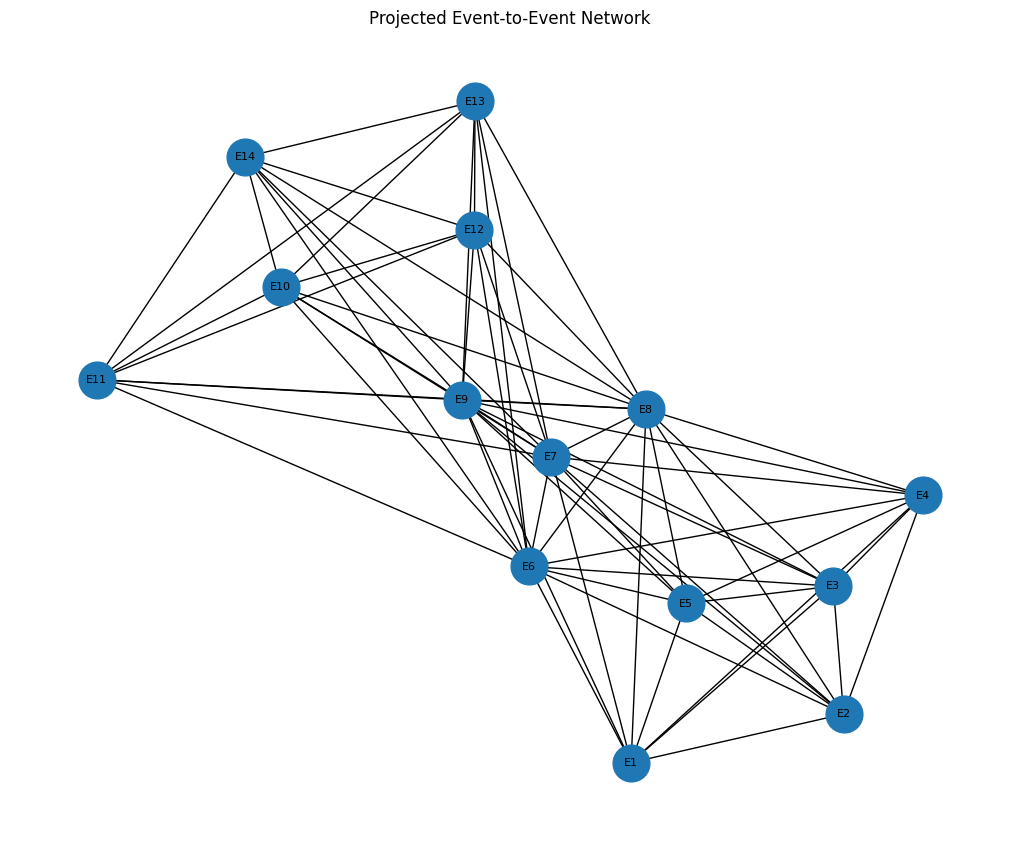

In [12]:
### Adding event only viz labled.
plt.figure(figsize=(10, 8))

pos_e = nx.spring_layout(E_weighted, seed=648)
nx.draw(E_weighted, pos_e, with_labels=True, node_size=700, font_size=8)

plt.title("Projected Event-to-Event Network")
plt.axis("off")
plt.show()

### Density Analysis 

In [13]:
print("Bipartite network density:", bipartite.density(G, women))
print("Women projection density:", nx.density(W))
print("Event projection density:", nx.density(E))

Bipartite network density: 0.3531746031746032
Women projection density: 0.9084967320261438
Event projection density: 0.7252747252747253


Looking a the density of the network, which tells us the actual connections to the possible connections. Specifically for the 1-node networks 
which were extracted, ~90 percent of the potential connections were actual connections for the women. Then, a bit lower was the event density, which 
at ~72%, implies about 70 percent of the potential event connections were made. OIVerall you can infer that 90 poercent of the women are connected, essentially a substantially connected social group. This notion is renforced by the events were attended by many of the same attendies.

However, for the 2 node network, having a 35% level of density for both node types. It is decent amount of overlap between attednies and events. This means that most of the women attennded some of the envent not all of them.

### Centrality Anlaysis

In [14]:
women_degree = dict(W.degree())
top_women = sorted(women_degree.items(), key=lambda x: x[1], reverse=True)

print("Top women by projected degree:")
for name, deg in top_women[:5]:
    print(name, deg)

Top women by projected degree:
Evelyn Jefferson 17
Theresa Anderson 17
Ruth DeSand 17
Verne Sanderson 17
Sylvia Avondale 17


The above highlights the women with the most "influence" via network centrality in the data. These women with the highest projected degree share event attendance with the largest number of other women. Thus making them more central within the social structure and potentially important connectors within the network.

In [15]:
event_degree = dict(E.degree())
top_events = sorted(event_degree.items(), key=lambda x: x[1], reverse=True)

print("Top events by projected degree:")
for name, deg in top_events[:5]:
    print(name, deg)

Top events by projected degree:
E6 13
E7 13
E8 13
E9 13
E1 8


Similarly, this outlines the events that are most central in the projected event network. Events with the most shared attendees, so they had overlapping groups of attendies. This can imply that they were important gathering times.

### Conclusion
The Davis Southern Women dataset shows how bipartite networks can be "flattened" or projected in to one-node networks for specfic subsets of metrics around the relationships behind speicfic node types, and how the multiple node types can imply relationships between those involved indivuiduals and events. When taken together, the projectred network metrics and the original bipartite network metrics can provide insights into the level of interconnectivity within a social structure, and the influendital pieces within that structure.